In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [33]:
%pip install -U scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 45.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 43.8 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Task 1: Create the dataset using Pandas
data = {
    'House_Size': [600, 800, 1000, 1200, 1400, 1600, 1800, 2000, 2200, 2400],
    'House_Price': [25, 32, 38, 45, 52, 58, 65, 72, 80, 87]
}

In [44]:
df = pd.DataFrame(data)
print("Task 1: First Few Records ")
print(df.head())


Task 1: First Few Records 
   House_Size  House_Price
0         600           25
1         800           32
2        1000           38
3        1200           45
4        1400           52


In [13]:
df.describe()

,House_Size,House_Price
count,10.000000,10.00000
mean,1500.000000,55.40000
std,605.530071,20.74287
min,600.000000,25.00000
25%,1050.000000,39.75000
50%,1500.000000,55.00000
75%,1950.000000,70.25000
max,2400.000000,87.00000


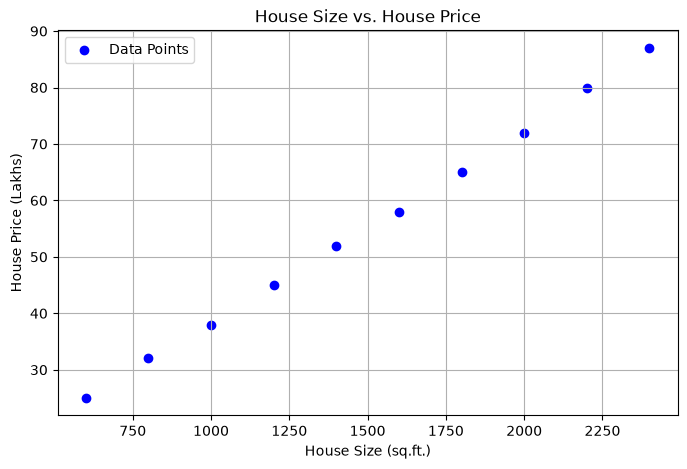

In [ ]:
# Task 2: Exploratory Data Visualization
plt.figure(figsize=(8, 5))
plt.scatter(df['House_Size'], df['House_Price'], color='blue', label='Data Points')
plt.xlabel('House Size (sq.ft.)')
plt.ylabel('House Price (Lakhs)')
plt.title('House Size vs. House Price')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
#Task 3: Split the dataset (80:20 ratio)
from sklearn.model_selection import train_test_split
X = df[['House_Size']]
y = df['House_Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:

#Task 4: Build Simple Linear Regression Model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.03]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['House_Size']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.914
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [36]:
# Task 5: Display Learned Model Parameters
theta_0 = model.intercept_
theta_1 = model.coef_[0]
print("--- Task 5: Model Parameters ---")
print(f"Regression Constant (theta_0): {theta_0:.4f}")
print(f"Regression Coefficient (theta_1): {theta_1:.4f}")

--- Task 5: Model Parameters ---
Regression Constant (theta_0): 3.9138
Regression Coefficient (theta_1): 0.0342


In [37]:
# Task 6: Predict and Compare on Test Dataset
y_pred_test = model.predict(X_test)
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_test})
print("--- Task 6: Test Set Comparison ---")
print(comparison_df)

--- Task 6: Test Set Comparison ---
   Actual  Predicted
8      80  79.206897
1      32  31.293103


In [40]:
# Task 7: Predict for Specific House Sizes
specific_sizes = np.array([[1500], [1700], [2500]])
specific_preds = model.predict(specific_sizes)
print("--- Task 7: Predictions for Specific Sizes ---")
for size, pred in zip(specific_sizes.ravel(), specific_preds):
    print(f"House Size: {size} sq.ft. --> Predicted Price: {pred:.2f} Lakhs")

--- Task 7: Predictions for Specific Sizes ---
House Size: 1500 sq.ft. --> Predicted Price: 55.25 Lakhs
House Size: 1700 sq.ft. --> Predicted Price: 62.09 Lakhs
House Size: 2500 sq.ft. --> Predicted Price: 89.47 Lakhs


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


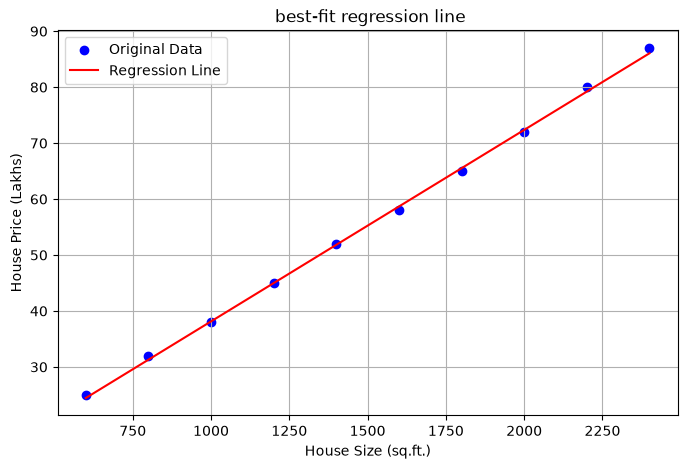

In [45]:
# Task 8: Plot Regression Line
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', label='Original Data')
plt.plot(X, model.predict(X), color='red', label='Regression Line')
plt.xlabel('House Size (sq.ft.)')
plt.ylabel('House Price (Lakhs)')
plt.title(' best-fit regression line')
plt.legend()
plt.grid(True)
plt.show()

In [46]:
# Task 9: Evaluate Model Performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
y_pred_all = model.predict(X)
mae = mean_absolute_error(y, y_pred_all)
mse = mean_squared_error(y, y_pred_all)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred_all)

print("--- Task 9: standard regression performance metrics ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

--- Task 9: standard regression performance metrics ---
Mean Absolute Error (MAE): 0.4879
Mean Squared Error (MSE): 0.3232
Root Mean Squared Error (RMSE): 0.5685
R2 Score: 0.9992


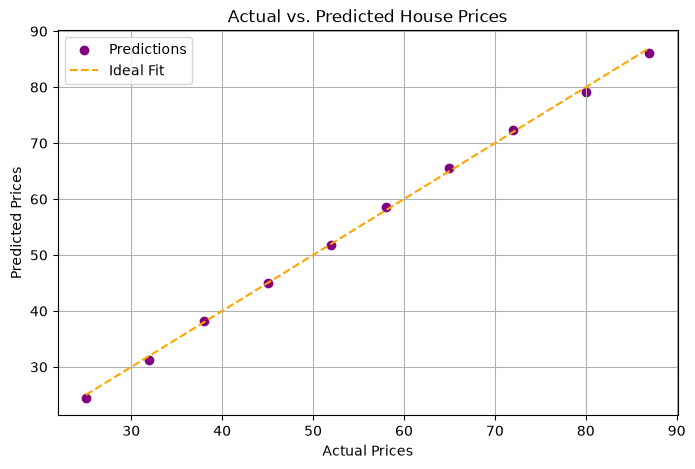

In [43]:
# Task 10: Plot Actual vs. Predicted Values
plt.figure(figsize=(8, 5))
plt.scatter(y, y_pred_all, color='purple', label='Predictions')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='orange', linestyle='--', label='Ideal Fit')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs. Predicted House Prices')
plt.legend()
plt.grid(True)
plt.show()